# (노트) 과적합
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [딥러닝, 응용통계]

### 오버피팅의 개념

`-` 정의: 모형의 일반화 성능이 떨어지는 현상

- 연습문제는 잘푸는데 실전에 약하다. 
- 

### 예제소개

`-` 아래와 같은 자료가 있다고 하자. 

In [302]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]

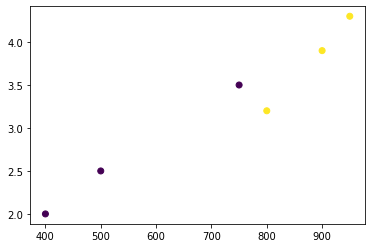

In [303]:
import matplotlib.pyplot as plt 
plt.scatter(toeic,gpa,marker='o',c=y)

In [304]:
import tensorflow as tf
import numpy as np 
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))

`-` $u\approx 0$ 또는 $v \approx 0.5$ 를 기준으로 적당히 나누면 되는것 같다. 

 - 참고로 $u=0$이면 $v=\frac{1}{2}$이다. 
 - 왜? $v=\frac{e^{u}}{1+e^{u}}$이므로 $u=0$을 대입하면 $v=\frac{1}{1+1}$

`-` $u=0 \Longleftrightarrow  0= toeic \times \frac{1}{100} + gpa \times 2.0 -14.5 \cdots (\star)$

시각화를 위해서 $(\star)$를 만족하는 $(toeic,gpa)$의 집합을 그리면 아래와 같다. 

- 그림을 위한 예비계산: $gpa=\frac{14.5-toeic\frac{1}{100}}{2}$

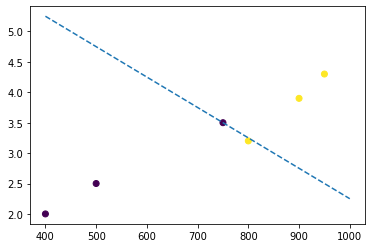

In [314]:
plt.scatter(toeic,gpa,marker='o',c=y)
_toeic=np.linspace(400,1000,1000)
_gpa=(14.5-_toeic/100)/2 # _gpa=(-b-w[0]*_toeic)/w[1]
plt.plot(_toeic,_gpa,'--')

`-` 사실 이건 아래와 같은 그림이다. 

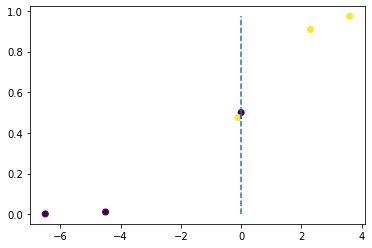

In [315]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')

`-` 그리고 아래와도 같은 그림이다. 

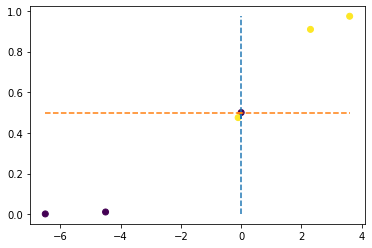

In [316]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')

`-` 정리를 해보자.  

`-` 모형 
 - (population) $y \approx v=f(u)=\frac{e^u}{1+e^u}, \quad u=\beta_0+\beta_1\times toeic +\beta_2\times gpa$
 - (sample) $y_i \approx v_i=f(u_i)=\frac{e^{u_i}}{1+e^{u_i}}, \quad u_i=\beta_0+\beta_1\times toeic_i +\beta_2\times gpa_i$

`-` (자료,계수값) $\to$ (그림) 

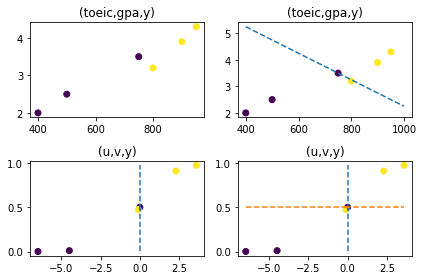

In [330]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure()
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 계수값을 바꾸면서 결과를 확인해보자. $\to$ GPA의 계수값을 상승시켜보자. 

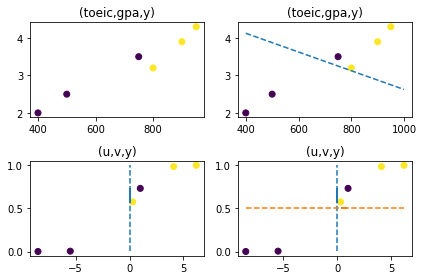

In [337]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,4])
b=np.array(-20.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure()
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 우측 위쪽의 그림에서 기울기가 평평해진다 $\to$ 극단적으로는 $x$축에 평행한 수직선 형태가 될듯 
 - $x$축에 평행한 수직선이라는 의미는 토익점수와 상관없이 GPA만 가지고 합격 불합격을 판단하는 구분자라는 의미

### 잘못된 분석을 하는 사례1: 너무 적은 $n$ 때문에.. 

`-` 우하향 직선이 아니라 우상향 직선을 아주 잘 그으면 100% 분리가 가능해보인다. 

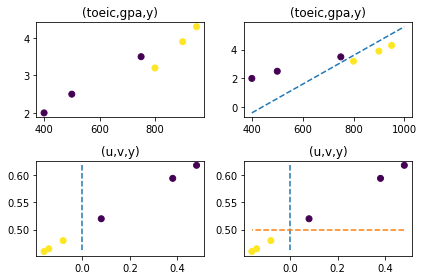

In [370]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([-2/1000,0.2])
b=np.array(0.88) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure()
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 모형 
 $$y \approx v=f(u)=\frac{e^u}{1+e^u}, \quad u=0.88+\frac{-2}{1000}\times toeic +0.2 \times gpa$$
 

토익점수가 오를수록 $u$의 값이 작아지고, $f(u)$의 값은 $0$에 가까워진다. 

극단적으로 어떤사람의 토익점수가 20만점이고, GPA=4.5라고 한다면, 

In [371]:
0.88 + -2/1000*200000+0.2*4.5 

-398.22

In [373]:
np.exp(-398.22)/(np.exp(-398.22)+1)

1.1356680725764854e-173

합격확률은 0이다. 

`-` 쉽게말해서 잘못된 모형이다. 

`-` 하지만 훈련상황에서는 100%적중률을 보인 우수한 모형이다 $\to$ 일반화성능이 약한 모형, 즉 overfitted 된 모형 

`-` 이러한 모형이 나온 원인? 데이터가 너무 적어서.. 

`-` 해결책? 데이터를 많이.. 

### 잘못된 분석을 하는 사례2: 너무 많은 $p$ 때문에.. 

In [ ]:
plt.plot()

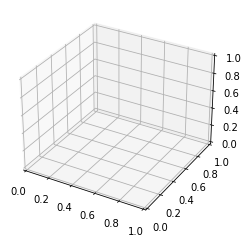

In [245]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.axes(projection='3d')

In [246]:
_x,_y = _X = np.meshgrid(toeic,gpa)
_u =_x*1/100+_y*2-14.5
_v = np.array(tf.nn.sigmoid(_u))

In [247]:
ax.plot_surface(_x,_y,_v)

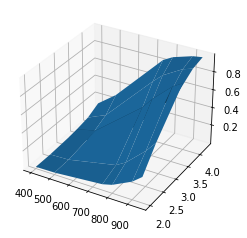

In [248]:
fig

In [142]:
_df=pd.DataFrame({'u':u,'v':v})
df=pd.concat([df,_df],axis=1)

In [143]:
sns.relplot()

,toeic,gpa,num,y,u,v,u,v
0,400,2.0,7,0,-6.5,0.001501,-6.5,0.001501
1,500,2.5,777,0,-4.5,0.010987,-4.5,0.010987
2,750,3.5,8,0,0.0,0.500000,0.0,0.500000
3,800,3.2,1,1,-0.1,0.475021,-0.1,0.475021
4,900,3.9,0,1,2.3,0.908877,2.3,0.908877
5,950,4.3,3,1,3.6,0.973403,3.6,0.973403


다음과 같이 학습했다고 하자. 

#### 사례2: 너무 큰 $p$

`-` 회귀분석 복습: $R^2$는 변수의 수가 늘어날수록 증가한다. 